In [1]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib import patches
import pandas as pd
from astropy.table import Table
import synthpop as sp
from mulens_rates import misc_utils
import pdb

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [2]:
ap_tab = Table.read('data/apjac8bd6/apjac8bd6t4_mrt.txt', format="ascii.cds")
ap_tab

Name,F127M,e_F127M,F139M,e_F139M,F153M,e_F153M,dRA,e_dRA,dDE,e_dDE,pmRA,e_pmRA,pmDE,e_pmDE,t0,Nobs,chi2RA,chi2DE,Pclust
,mag,mag,mag,mag,mag,mag,arcsec,arcsec,arcsec,arcsec,mas / yr,mas / yr,mas / yr,mas / yr,yr,,,,
str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
Q0000001,13.71,0.02,12.94,0.02,11.03,0.02,-21.16637,0.00048,-91.72974,0.00052,-1.96,0.19,-3.84,0.21,2013.4494,4,5.7,1.62,0.0
Q0000002,13.16,0.0,12.14,0.01,11.15,0.01,5.61601,0.00022,1.70905,0.00025,-0.98,0.09,-2.36,0.09,2013.4065,4,1.17,0.9,0.93
Q0000003,13.38,0.01,12.71,0.01,11.2,0.01,35.65604,0.00035,-35.1523,0.00045,-0.26,0.14,-5.52,0.16,2013.787,4,1.76,0.61,0.0
Q0000004,13.52,0.01,12.38,0.02,11.28,0.02,-23.11858,0.00034,38.75195,0.00039,-1.18,0.14,-2.23,0.15,2013.5401,4,0.1,0.11,0.8
Q0000005,13.4,0.01,12.38,0.0,11.36,0.02,10.38729,0.00027,18.52431,0.00033,-0.99,0.12,-2.46,0.12,2013.2733,4,0.15,0.74,0.86
Q0000006,13.77,0.01,12.61,0.01,11.43,0.01,41.24882,0.0004,-28.44969,0.00049,-0.82,0.16,-2.5,0.18,2013.821,4,0.81,0.31,0.78
Q0000007,14.29,0.01,13.05,0.01,11.49,0.02,-4.38456,0.00026,-74.41212,0.0003,-1.4,0.11,-3.12,0.12,2013.4136,4,3.12,0.17,0.0
Q0000008,13.58,0.01,12.77,0.01,11.54,0.01,40.80177,0.00036,-7.84586,0.00043,-1.11,0.14,-2.56,0.16,2013.9173,4,1.66,0.14,0.66


In [3]:
tab0 = ap_tab[ap_tab['Pclust']<0.5].to_pandas()

In [4]:
# mod = 0
# mod = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
#                           model_name="Huston2025", name_for_output='quintuplet',
#                           chosen_bands=["WFC3_IR_F127M", "WFC3_IR_F139M", "WFC3_IR_F153M"],
#                          maglim=['WFC3_IR_F153M', 99, "remove"], output_location="outputfiles/quintuplet",
#                          skip_lowmass_stars=True)
# mod.init_populations()

In [5]:
rd_coord = SkyCoord(ra='17:46:14.68579', dec='−28:49:38.99169', unit=(u.hourangle, u.degree))
coord = rd_coord.transform_to('galactic')
print(coord)
coord
solang = (132*124)/60**4
solang

<SkyCoord (Galactic): (l, b) in deg
    (0.16398615, -0.06022403)>


0.001262962962962963

In [8]:
#sp_tab = mod.process_location(l_deg=coord.l.degree, b_deg=coord.b.degree, solid_angle=solang)
sp_tab = pd.read_hdf("outputfiles/quintuplet/quintuplet_l0.164_b-0.060.h5")

In [11]:
from mulens_rates import misc_utils

In [9]:
# tab_bl = misc_utils.calc_blends(sp_tab[sp_tab["WFC3_IR_F153M"]<30], 
#                                 filters=["WFC3_IR_F127M", "WFC3_IR_F139M", "WFC3_IR_F153M"],
#                                 blend_rad=0.16/2/3600)
# tab_bl.to_csv(f'outputfiles/quintuplet/blended_quintuplet.csv', index=False)

In [10]:
# tab_bl = pd.read_csv('outputfiles/quintuplet/blended_quintuplet.csv')

In [11]:
1.22 * 15336.98 / (2.4*1e10) * 180/np.pi * 3600

0.1608101930792092

In [12]:
use_stars = sp_tab[sp_tab['WFC3_IR_F153M']< 25]
bl = misc_utils.calc_blends(use_stars, blend_rad=0.08/3600, filters=['WFC3_IR_F127M','WFC3_IR_F139M','WFC3_IR_F153M'])

/Users/mhuston/code/mulens_rates/mulens_rates/misc_utils.py:47: UserWarning: No primary_filter provided. Using WFC3_IR_F127M to sort stars and flux-weight additional parameters.
  warnings.warn(f"No primary_filter provided. Using {filters[0]}"+


  0%|          | 0/923829 [00:00<?, ?it/s]

In [13]:
sp_tab

,pop,iMass,age,Fe/H_initial,Mass,Dist,l,b,vr_bc,mul,mub,A_Ks,WFC3_IR_F127M,WFC3_IR_F139M,WFC3_IR_F153M
0,0.0,0.119460,10.000000,0.310610,0.119459,3.587991,0.179966,-0.064286,21.094878,-0.043864,-2.828043,0.471169,24.321362,24.367367,23.674623
1,0.0,0.183930,10.000000,-0.335807,0.183927,3.721396,0.161709,-0.044491,66.637738,-1.487824,-5.300881,0.468904,22.975995,22.581451,22.063348
2,0.0,0.299455,10.000000,0.027256,0.299450,3.818434,0.152758,-0.071299,-71.169990,-6.341048,-0.741506,0.514616,22.295092,21.898720,21.358935
3,0.0,0.759107,10.000000,0.182196,0.759031,3.911181,0.148657,-0.067807,-95.534211,1.168711,-1.200512,0.517308,19.466196,19.006072,18.487299
4,0.0,0.373742,10.000000,0.237142,0.373735,4.012088,0.160028,-0.041719,-67.519280,-2.341398,-0.714756,0.513824,21.991885,21.607932,21.071002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4097790,10.0,0.318246,8.147893,-0.312349,0.318241,24.912145,0.147950,-0.051097,-20.423937,-3.580549,-0.064147,3.387141,35.531763,33.494605,31.352994
4097791,10.0,0.181169,8.793878,-0.269906,0.181167,24.901918,0.161436,-0.053390,-27.763842,-2.096851,-0.022971,3.353785,36.585400,34.586682,32.459093
4097792,10.0,0.459492,9.012488,-0.479962,0.459478,24.998471,0.157459,-0.076833,-55.405133,-2.113523,-0.064500,3.329111,34.384346,32.361892,30.245509
4097793,10.0,0.107659,7.711269,-0.174002,0.107658,24.957229,0.170530,-0.056630,-9.072345,-3.349756,-0.107294,3.430868,38.083902,36.134430,33.911894


In [14]:
tab = tab0
tab

,Name,F127M,e_F127M,F139M,e_F139M,F153M,e_F153M,dRA,e_dRA,dDE,e_dDE,pmRA,e_pmRA,pmDE,e_pmDE,t0,Nobs,chi2RA,chi2DE,Pclust
0,Q0000001,13.71,0.02,12.94,0.02,11.03,0.02,-21.16637,0.00048,-91.72974,0.00052,-1.96,0.19,-3.84,0.21,2013.4494,4,5.70,1.62,0.0
1,Q0000003,13.38,0.01,12.71,0.01,11.20,0.01,35.65604,0.00035,-35.15230,0.00045,-0.26,0.14,-5.52,0.16,2013.7870,4,1.76,0.61,0.0
2,Q0000007,14.29,0.01,13.05,0.01,11.49,0.02,-4.38456,0.00026,-74.41212,0.00030,-1.40,0.11,-3.12,0.12,2013.4136,4,3.12,0.17,0.0
3,Q0000011,12.38,0.01,12.15,0.01,11.88,0.01,8.95795,0.00016,-2.73526,0.00021,0.35,0.07,3.87,0.08,2013.3529,4,0.74,1.23,0.0
4,Q0000012,14.50,0.01,13.26,0.00,11.89,0.01,-92.79289,0.00066,-12.23482,0.00050,-1.41,0.25,-5.82,0.19,2013.6859,4,0.15,0.11,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38924,Q0040495,24.24,0.51,24.37,0.77,24.17,0.78,55.05652,0.00274,-26.81463,0.00280,6.58,0.96,-3.46,1.00,2013.5817,4,2.93,2.99,0.0
38925,Q0040496,25.69,0.75,25.19,1.19,24.19,0.88,-22.36024,0.00349,-46.18441,0.00342,-7.09,1.38,-4.73,1.37,2013.1349,4,1.67,2.62,0.0
38926,Q0040497,25.43,0.69,25.41,0.75,24.26,0.71,-23.06465,0.00357,59.91513,0.00339,-4.14,1.35,-9.09,1.29,2013.5458,4,3.77,4.86,0.0
38927,Q0040498,25.31,1.00,24.67,0.27,24.31,0.81,5.49917,0.00269,30.48492,0.00268,-3.41,1.28,-5.39,1.27,2012.5942,4,0.28,3.32,0.0


In [15]:
tab_coords = SkyCoord(ra=rd_coord.ra+tab.dRA.to_numpy()/np.cos(rd_coord.dec.rad)*u.arcsec, dec=rd_coord.dec+tab.dDE.to_numpy()*u.arcsec, 
                      pm_ra_cosdec=tab.pmRA.to_numpy()*u.mas/u.year, pm_dec=tab.pmDE.to_numpy()*u.mas/u.year).transform_to('galactic')

In [16]:
sp_tab_nn = sp_tab[sp_tab['pop']!=2.0]

/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_95405/1668523287.py:12: RuntimeWarning: divide by zero encountered in divide
  ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_95405/1668523287.py:12: RuntimeWarning: invalid value encountered in multiply
  ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_95405/1668523287.py:14: RuntimeWarning: divide by zero encountered in divide
  print(np.nansum(spcts/cts * 1/(spcts/cts*np.sqrt(cts)/cts)**2)/np.nansum(1/(spcts/cts*np.sqrt(cts)/cts)**2))
/var/folders/_z/fn__fgrs2wqgsmbvw8bvrr0r0000gn/T/ipykernel_95405/1668523287.py:14: RuntimeWarning: invalid value encountered in multiply
  print(np.nansum(spcts/cts * 1/(spcts/cts*np.sqrt(cts)/cts)**2)/np.nansum(1/(spcts/cts*np.sqrt(cts)/cts)**2))


1.5469867131486437
1.3706878096488884
1.2935811587897685


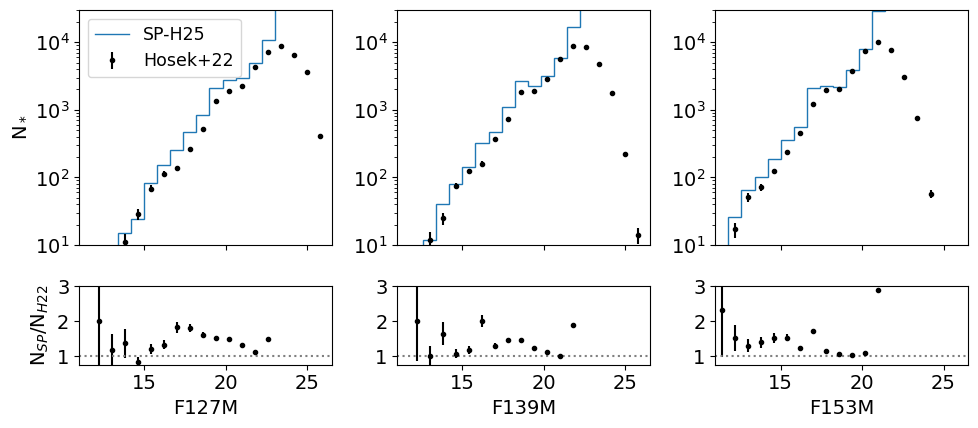

In [17]:
plt.rcParams.update({'font.size': 14})
fig,ax = plt.subplots(nrows=2,ncols=3, figsize=(10,4.5), height_ratios=[3,1], sharex=True)
filts = [127,139,153]
for i in range(len(filts)):
    cts,bins = np.histogram(tab[f'F{filts[i]}M'], bins=np.linspace(11,27, 21))
    ax[0][i].errorbar(bins[:-1]+np.diff(bins)/2, cts, yerr=np.sqrt(cts), label='Hosek+22',
                     linestyle='none', marker='.', c='k')
    spcts,bins = np.histogram(sp_tab[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    spcts_nn,bins = np.histogram(sp_tab_nn[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    ax[0][i].stairs(spcts, bins, label='SP-H25')
    #ax[0][i].stairs(spcts_nn, bins, label='SP-H25-NN')
    ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
                     linestyle='none', marker='.', c='k')
    print(np.nansum(spcts/cts * 1/(spcts/cts*np.sqrt(cts)/cts)**2)/np.nansum(1/(spcts/cts*np.sqrt(cts)/cts)**2))
    ax[1][i].set_ylim(0.75,3.0)
    ax[1][i].axhline([1], c='gray', linestyle=':')
    ax[0][i].set_yscale('log')
    ax[1][i].set_xlabel(f'F{filts[i]}M')
    ax[0][i].set_xlim(11,26.5)
    ax[0][i].set_ylim(10, 3e4)
ax[0][0].set_ylabel(r'N$_*$')
ax[1][0].set_ylabel(r'N$_{SP}$/N$_{H22}$')
ax[0][0].legend(fontsize=12.5, frameon=True)
fig.tight_layout()
fig.savefig('figures/nsd_quintuplet_lf_hosek22.png')
fig.savefig('figures/nsd_quintuplet_lf_hosek22.pdf')

In [ ]:
plt.rcParams.update({'font.size': 14})
fig,ax = plt.subplots(nrows=2,ncols=3, figsize=(10,4.5), height_ratios=[3,1], sharex=True)
filts = [127,139,153]
for i in range(len(filts)):
    cts,bins = np.histogram(tab[f'F{filts[i]}M'], bins=np.linspace(11,27, 21))
    ax[0][i].errorbar(bins[:-1]+np.diff(bins)/2, cts, yerr=np.sqrt(cts), label='Hosek+22',
                     linestyle='none', marker='.', c='k')
    spcts,bins = np.histogram(tab_bl[f'WFC3_IR_F{filts[i]}M'], bins=bins)
    ax[0][i].stairs(spcts, bins, label='SP-H25')
    #ax[0][i].stairs(spcts_nn, bins, label='SP-H25-NN')
    ax[1][i].errorbar(bins[:-1]+np.diff(bins)/2, spcts/cts, yerr=spcts/cts*np.sqrt(cts)/cts,
                     linestyle='none', marker='.', c='k')
    ax[1][i].set_ylim(0.75,3.0)
    ax[1][i].axhline([1], c='gray', linestyle=':')
    ax[0][i].set_yscale('log')
    ax[1][i].set_xlabel(f'F{filts[i]}M')
    ax[0][i].set_xlim(11,26.5)
    ax[0][i].set_ylim(10, 3e4)
ax[0][0].set_ylabel(r'N$_*$')
ax[1][0].set_ylabel(r'N$_{SP}$/N$_{H22}$')
ax[0][0].legend(fontsize=12.5, frameon=True)
fig.tight_layout()
fig.savefig('figures/nsd_quintuplet_lf_hosek22_bl.png')
fig.savefig('figures/nsd_quintuplet_lf_hosek22_bl.pdf')

mul means -5.406199733654529 -5.162436721170749
mul mean errs 0.028618780823376558 0.026031259744953655
-0.2682523935842017 -0.2917920432955514
mul spread 3.277568919343843 2.793118993033976
mul spread errs 0.02023653398950109 0.01840688028848513
2.178061640925609 1.7726960147392026


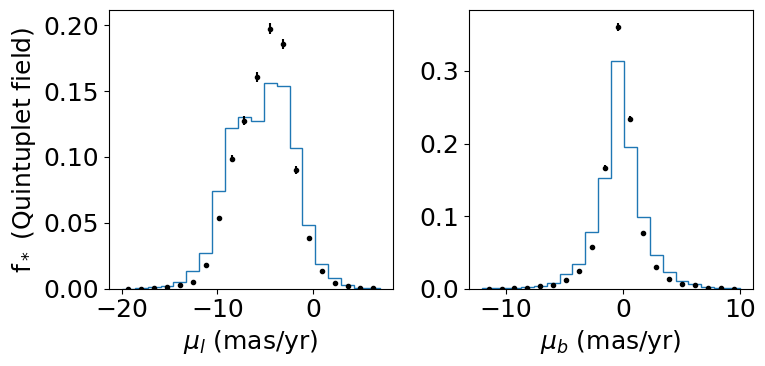

In [29]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

sp_tab_cut = sp_tab[sp_tab['WFC3_IR_F153M']<20]
sp_tab_nn_cut = sp_tab_nn[sp_tab_nn['WFC3_IR_F153M']<20]
cts_mul, bins = np.histogram(tab_coords.pm_l_cosb.value[tab['F153M']<20], bins=np.linspace(-20,7, 21))
ax[0].errorbar(bins[:-1]+np.diff(bins)/2, cts_mul/np.sum(cts_mul), yerr=np.sqrt(cts_mul)/np.sum(cts_mul), 
               label="H+22", c='k', marker='.', linestyle='none')
n_obs = sum(cts_mul)
sp_cts_mul,_ = np.histogram(sp_tab_cut['mul'], bins=bins)
ax[0].stairs(sp_cts_mul/np.sum(sp_cts_mul), bins, label='SP-H25')
sp_cts_mul_nn,_ = np.histogram(sp_tab_nn_cut['mul'], bins=bins)
#ax[0].stairs(sp_cts_mul_nn/np.sum(sp_cts_mul_nn), bins, label='SP-H25\nNo NSD')
ax[0].set_xlabel(r'$\mu_l$ (mas/yr)')
ax[0].set_ylabel(r'f$_*$ (Quintuplet field)')
#ax[0].legend()
#ax[0].set_xlim(-22,6)

cts_mub, bins = np.histogram(tab_coords.pm_b.value[tab['F153M']<20], bins=np.linspace(-12,10, 21))
ax[1].errorbar(bins[:-1]+np.diff(bins)/2, cts_mub/np.sum(cts_mub), yerr=np.sqrt(cts_mub)/np.sum(cts_mub), 
               label="H+22", c='k', marker='.', linestyle='none')
n_obs = sum(cts_mub)
sp_cts_mub,_ = np.histogram(sp_tab_cut.mub, bins=bins)
ax[1].stairs(sp_cts_mub/np.sum(sp_cts_mub), bins, label='SP-H25')
sp_cts_mub_nn,_ = np.histogram(sp_tab_nn_cut['mub'], bins=bins)
print('mul means', np.mean(sp_tab_cut['mul']), np.mean(tab_coords.pm_l_cosb.value[tab['F153M']<20]))
print('mul mean errs', np.std(sp_tab_cut['mul'])/np.sqrt(len(sp_tab_cut)), 
      np.std(tab_coords.pm_l_cosb.value[tab['F153M']<20]/np.sqrt(len(tab[tab['F153M']<20]))))
print(np.mean(sp_tab_cut['mub']), np.mean(tab_coords.pm_b.value[tab['F153M']<20]))
print('mul spread', np.std(sp_tab_cut['mul']), np.std(tab_coords.pm_l_cosb.value[tab['F153M']<20]))
print('mul spread errs', np.std(sp_tab_cut['mul'])/np.sqrt(2*len(sp_tab_cut)), 
      np.std(tab_coords.pm_l_cosb.value[tab['F153M']<20]/np.sqrt(2*len(tab[tab['F153M']<20]))))
print(np.std(sp_tab_cut['mub']), np.std(tab_coords.pm_b.value[tab['F153M']<20]))
#ax[1].stairs(sp_cts_mub_nn/np.sum(sp_cts_mub_nn), bins, label='SP-H25\nNo NSD')
ax[1].set_xlabel(r'$\mu_b$ (mas/yr)')
#ax[0].legend(fontsize=16)
fig.tight_layout()
fig.savefig('figures/nsd_quintuplet_pm_hosek22.png')
fig.savefig('figures/nsd_quintuplet_pm_hosek22.pdf')